In [ ]:
from pathlib import Path

from IPython.display import Image, Markdown, display



STATIC_IMAGE_DIR = Path("/kaggle/input/notebook-static-images-public")

display(Markdown("## Saved analysis figures"))

for image_path in sorted(STATIC_IMAGE_DIR.glob("segmentation-*.png")):

    display(Markdown(f"**{image_path.stem}**"))

    display(Image(filename=str(image_path)))

# Sartorius Cell Instance Segmentation - Mask R-CNN

# CELL 1 - IMPORT LIBRARIES

In [ ]:
# ============================================
# IMPORTS
# ============================================

import os
import gc
import json
import random

import cv2
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader

from torchvision.models.detection import maskrcnn_resnet50_fpn
from torchvision.models.detection.rpn import AnchorGenerator

from torchvision.transforms import functional as TF

from torch.amp import autocast, GradScaler

matplotlib.rcParams["figure.dpi"] = 110

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# CELL 2 - CONFIG

In [2]:
# ============================================
# CONFIG
# ============================================


class CFG:

    # paths (local reproduction)
    DATA_DIR = "/home/Data_Drive_8TB/kykim/7. Kaggle/Cell_Instance_Segmentation"
    TRAIN_IMG_DIR = f"{DATA_DIR}/train"
    TEST_IMG_DIR = f"{DATA_DIR}/test"
    TRAIN_CSV = f"{DATA_DIR}/train.csv"

    OUT_DIR = f"{DATA_DIR}/outputs_augmented"
    SUBMISSION_PATH = "/home/Data_Drive_8TB/kykim/0. Jupyter/Kaggle/cell-Seg/submission_b.csv"

    # torchvision COCO-pretrained Mask R-CNN weights (torch hub cache)
    BACKBONE_WEIGHTS = os.path.expanduser(
        "~/.cache/torch/hub/checkpoints/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth"
    )

    # training
    IMG_SIZE = 512
    PATCH_SIZE = 256
    STRIDE = 128

    BATCH_SIZE = 2
    NUM_WORKERS = 4

    EPOCHS = 20
    LR = 2e-4
    WEIGHT_DECAY = 1e-4

    NUM_CLASSES = 2

    AMP = True

    EARLY_STOPPING = 5

    GRAD_CLIP = 1.0

    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

    THRESHOLD = 0.5
    THRESHOLD_MIN = 0.30
    THRESHOLD_MAX = 0.75

    MIN_MASK_AREA = 30

    N_ROUNDS = 3      # number of random subsets per threshold
    SUBSET_SIZE = 30  # images per subset

    HFLIP_PROB = 0.5
    VFLIP_PROB = 0.5
    ROTATE_PROB = 0.75
    ROTATE_RANGE = (-30.0, 30.0)
    SCALE_PROB = 0.5
    SCALE_RANGE = (0.85, 1.15)


os.makedirs(CFG.OUT_DIR, exist_ok=True)

print("Device:", CFG.DEVICE)
if CFG.DEVICE == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
print("Weights exist:", os.path.exists(CFG.BACKBONE_WEIGHTS))

Device: cuda
GPU: NVIDIA RTX A5000
Weights exist: True


# CELL 3 - LOAD DATASET

In [3]:
# ============================================
# LOAD DATA
# ============================================

train_df = pd.read_csv(CFG.TRAIN_CSV)

print("Train rows:", len(train_df))

image_ids = train_df["id"].unique()

train_ids, val_ids = train_test_split(
    image_ids,
    test_size=0.2,
    random_state=42
)

print("Train images:", len(train_ids))
print("Val images:", len(val_ids))
print("Number of images:", len(image_ids))

# annotation index (much faster than filtering the dataframe per item)
ANN = train_df.groupby("id")["annotation"].apply(list).to_dict()

cells_per_image = train_df.groupby("id").size()

data_stats = {
    "n_annotations": int(len(train_df)),
    "n_images": int(len(image_ids)),
    "n_train": int(len(train_ids)),
    "n_val": int(len(val_ids)),
    "cell_type_counts": train_df["cell_type"].value_counts().to_dict(),
    "cells_per_image_mean": float(cells_per_image.mean()),
    "cells_per_image_median": float(cells_per_image.median()),
    "cells_per_image_min": int(cells_per_image.min()),
    "cells_per_image_max": int(cells_per_image.max()),
}

print(json.dumps(data_stats, indent=2))

train_df.head()

Train rows: 73585
Train images: 484
Val images: 122
Number of images: 606
{
  "n_annotations": 73585,
  "n_images": 606,
  "n_train": 484,
  "n_val": 122,
  "cell_type_counts": {
    "shsy5y": 52286,
    "cort": 10777,
    "astro": 10522
  },
  "cells_per_image_mean": 121.42739273927393,
  "cells_per_image_median": 46.0,
  "cells_per_image_min": 4,
  "cells_per_image_max": 790
}


,id,annotation,width,height,cell_type,plate_time,sample_date,sample_id,elapsed_timedelta
0,0030fd0e6378,118145 6 118849 7 119553 8 120257 8 120961 9 1...,704,520,shsy5y,11h30m00s,2019-06-16,shsy5y[diff]_E10-4_Vessel-714_Ph_3,0 days 11:30:00
1,0030fd0e6378,189036 1 189739 3 190441 6 191144 7 191848 8 1...,704,520,shsy5y,11h30m00s,2019-06-16,shsy5y[diff]_E10-4_Vessel-714_Ph_3,0 days 11:30:00
2,0030fd0e6378,173567 3 174270 5 174974 5 175678 6 176382 7 1...,704,520,shsy5y,11h30m00s,2019-06-16,shsy5y[diff]_E10-4_Vessel-714_Ph_3,0 days 11:30:00
3,0030fd0e6378,196723 4 197427 6 198130 7 198834 8 199538 8 2...,704,520,shsy5y,11h30m00s,2019-06-16,shsy5y[diff]_E10-4_Vessel-714_Ph_3,0 days 11:30:00
4,0030fd0e6378,167818 3 168522 5 169225 7 169928 8 170632 9 1...,704,520,shsy5y,11h30m00s,2019-06-16,shsy5y[diff]_E10-4_Vessel-714_Ph_3,0 days 11:30:00


# CELL 4 - RLE UTILS

In [4]:
# ============================================
# RLE FUNCTIONS
# ============================================


def rle_decode(mask_rle, shape):

    s = mask_rle.split()

    starts = np.asarray(s[0::2], dtype=int)
    lengths = np.asarray(s[1::2], dtype=int)

    starts -= 1
    ends = starts + lengths

    img = np.zeros(shape[0] * shape[1], dtype=np.uint8)

    for lo, hi in zip(starts, ends):
        img[lo:hi] = 1

    # row-major layout (verified: yields one connected component per cell)
    return img.reshape(shape)


def rle_encode(img):

    pixels = img.flatten()

    pixels = np.concatenate([[0], pixels, [0]])

    runs = np.where(pixels[1:] != pixels[:-1])[0] + 1

    runs[1::2] -= runs[::2]

    return " ".join(str(x) for x in runs)


_r = train_df.iloc[0]
_m = rle_decode(_r["annotation"], (_r["height"], _r["width"]))
print("round-trip ok:", rle_encode(_m) == " ".join(_r["annotation"].split()))
print("connected components:", cv2.connectedComponents(_m)[0] - 1)

round-trip ok: True
connected components: 1


# CELL 5 - VISUALIZATION

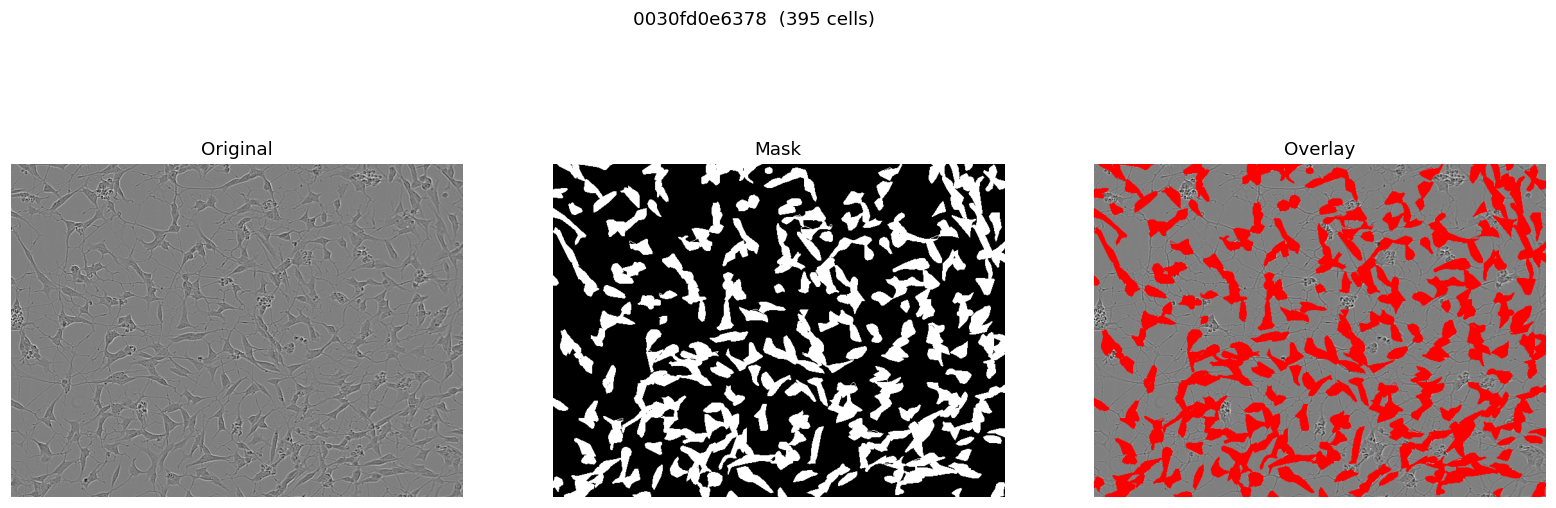

In [5]:
# ============================================
# VISUALIZE DATA
# ============================================


def visualize_sample(image_id, save_path=None):

    image_path = f"{CFG.TRAIN_IMG_DIR}/{image_id}.png"

    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    mask = np.zeros(image.shape[:2], dtype=np.uint8)

    for rle in ANN[image_id]:
        mask = np.maximum(mask, rle_decode(rle, image.shape[:2]))

    overlay = image.copy()
    overlay[mask == 1] = [255, 0, 0]

    fig, ax = plt.subplots(1, 3, figsize=(18, 6))

    ax[0].imshow(image)
    ax[0].set_title("Original")

    ax[1].imshow(mask, cmap="gray")
    ax[1].set_title("Mask")

    ax[2].imshow(overlay)
    ax[2].set_title("Overlay")

    for a in ax:
        a.axis("off")

    fig.suptitle(f"{image_id}  ({len(ANN[image_id])} cells)")

    if save_path:
        fig.savefig(save_path, bbox_inches="tight")

    plt.show()


visualize_sample(image_ids[0], save_path=f"{CFG.OUT_DIR}/fig_ground_truth.png")

# CELL 6 - PATCH GENERATION

In [6]:
# ============================================
# PATCH GENERATOR
# ============================================


def generate_patches(img, mask):

    patches = []

    h, w = img.shape[:2]

    for y in range(0, h - CFG.PATCH_SIZE + 1, CFG.STRIDE):
        for x in range(0, w - CFG.PATCH_SIZE + 1, CFG.STRIDE):

            img_patch = img[y:y + CFG.PATCH_SIZE, x:x + CFG.PATCH_SIZE]
            mask_patch = mask[y:y + CFG.PATCH_SIZE, x:x + CFG.PATCH_SIZE]

            patches.append((img_patch, mask_patch))

    return patches

# CELL 7 - AUGMENTATION

In [7]:
# ============================================
# INSTANCE-SAFE GEOMETRIC AUGMENTATION
# ============================================


def resize_and_center_crop_or_pad(image, masks, scale):

    h, w = image.shape[:2]
    scaled_h = max(1, int(round(h * scale)))
    scaled_w = max(1, int(round(w * scale)))

    image_scaled = cv2.resize(image, (scaled_w, scaled_h), interpolation=cv2.INTER_LINEAR)
    masks_scaled = np.stack([
        cv2.resize(mask, (scaled_w, scaled_h), interpolation=cv2.INTER_NEAREST)
        for mask in masks
    ])

    if scaled_h >= h:
        src_y = (scaled_h - h) // 2
        dst_y = 0
        copy_h = h
    else:
        src_y = 0
        dst_y = (h - scaled_h) // 2
        copy_h = scaled_h

    if scaled_w >= w:
        src_x = (scaled_w - w) // 2
        dst_x = 0
        copy_w = w
    else:
        src_x = 0
        dst_x = (w - scaled_w) // 2
        copy_w = scaled_w

    image_out = np.zeros_like(image)
    masks_out = np.zeros((len(masks), h, w), dtype=np.uint8)

    image_out[dst_y:dst_y + copy_h, dst_x:dst_x + copy_w] = image_scaled[
        src_y:src_y + copy_h, src_x:src_x + copy_w
    ]
    masks_out[:, dst_y:dst_y + copy_h, dst_x:dst_x + copy_w] = masks_scaled[
        :, src_y:src_y + copy_h, src_x:src_x + copy_w
    ]

    return image_out, masks_out


def augment(image, masks):

    if np.random.rand() < CFG.HFLIP_PROB:
        image = np.fliplr(image)
        masks = np.flip(masks, axis=2)

    if np.random.rand() < CFG.VFLIP_PROB:
        image = np.flipud(image)
        masks = np.flip(masks, axis=1)

    if np.random.rand() < CFG.ROTATE_PROB:
        h, w = image.shape[:2]
        angle = np.random.uniform(*CFG.ROTATE_RANGE)
        matrix = cv2.getRotationMatrix2D((w / 2, h / 2), angle, 1.0)
        image = cv2.warpAffine(
            image, matrix, (w, h), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REFLECT_101
        )
        masks = np.stack([
            cv2.warpAffine(
                mask, matrix, (w, h), flags=cv2.INTER_NEAREST,
                borderMode=cv2.BORDER_CONSTANT
            )
            for mask in masks
        ])

    if np.random.rand() < CFG.SCALE_PROB:
        scale = np.random.uniform(*CFG.SCALE_RANGE)
        image, masks = resize_and_center_crop_or_pad(image, masks, scale)

    return image.copy(), masks.copy()

# CELL 8 - DATASET CLASS

In [8]:
# ============================================
# DATASET
# ============================================


class CellDataset(Dataset):

    def __init__(self, image_ids, train=True):

        self.image_ids = list(image_ids)
        self.train = train

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):

        image_id = self.image_ids[idx]

        path = f"{CFG.TRAIN_IMG_DIR}/{image_id}.png"

        image = cv2.imread(path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        h, w = image.shape[:2]

        masks = []

        for rle in ANN[image_id]:

            m = rle_decode(rle, (h, w))

            masks.append(m)

        masks = np.stack(masks)

        if self.train:
            image, masks = augment(image, masks)

        valid_masks = []
        boxes = []

        for m in masks:
            pos = np.where(m)

            if pos[0].size == 0:
                continue

            xmin, xmax = int(pos[1].min()), int(pos[1].max()) + 1
            ymin, ymax = int(pos[0].min()), int(pos[0].max()) + 1

            if xmax <= xmin or ymax <= ymin:
                continue

            valid_masks.append(m)
            boxes.append([xmin, ymin, xmax, ymax])

        if valid_masks:
            masks = np.stack(valid_masks)
        else:
            masks = np.zeros((0, *image.shape[:2]), dtype=np.uint8)

        target = {
            "boxes": torch.as_tensor(boxes, dtype=torch.float32).reshape(-1, 4),
            "labels": torch.ones((len(boxes),), dtype=torch.int64),
            "masks": torch.as_tensor(masks, dtype=torch.uint8),
        }

        image = TF.to_tensor(image)

        return image, target


def collate_fn(batch):
    return tuple(zip(*batch))


_img, _tgt = CellDataset(train_ids, train=True)[0]
print(_img.shape, _tgt["boxes"].shape, _tgt["masks"].shape)

torch.Size([3, 520, 704]) torch.Size([36, 4]) torch.Size([36, 520, 704])


# CELL 9 - MODEL

In [9]:
# ============================================
# MODEL
# ============================================

from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor

print("Initializing Mask R-CNN...")

# 1. Build architecture (nothing is downloaded at construction time)
model = maskrcnn_resnet50_fpn(weights=None, weights_backbone=None)

# 2. Load local pretrained weights
print("Loading pretrained MaskRCNN weights from:", CFG.BACKBONE_WEIGHTS)

state_dict = torch.load(CFG.BACKBONE_WEIGHTS, map_location="cpu")

model.load_state_dict(state_dict)

print("Pretrained weights loaded!")

# 3. Replace classification head
in_features = model.roi_heads.box_predictor.cls_score.in_features

model.roi_heads.box_predictor = FastRCNNPredictor(
    in_features,
    CFG.NUM_CLASSES
)

# 4. Replace mask head
in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels

model.roi_heads.mask_predictor = MaskRCNNPredictor(
    in_features_mask,
    256,
    CFG.NUM_CLASSES
)

# 5. These images contain hundreds of cells, so raise the detection budget
model.roi_heads.detections_per_img = 600
model.rpn._post_nms_top_n = {"training": 2000, "testing": 2000}

model.to(CFG.DEVICE)

print("Model ready on device:", CFG.DEVICE)

Initializing Mask R-CNN...


Loading pretrained MaskRCNN weights from: /home/Data_Drive_8TB/kykim/.cache/torch/hub/checkpoints/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth
Pretrained weights loaded!


/tmp/ipykernel_3939439/3813648130.py:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(CFG.BACKBONE_WEIGHTS, map_location="cpu")


Model ready on device: cuda


# CELL 10 - DATALOADER

In [10]:
# ============================================
# DATALOADER
# ============================================

train_dataset = CellDataset(train_ids, train=True)
val_dataset = CellDataset(val_ids, train=False)

train_loader = DataLoader(
    train_dataset,
    batch_size=CFG.BATCH_SIZE,
    shuffle=True,
    num_workers=CFG.NUM_WORKERS,
    collate_fn=collate_fn,
    persistent_workers=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=CFG.BATCH_SIZE,
    shuffle=False,
    num_workers=CFG.NUM_WORKERS,
    collate_fn=collate_fn,
    persistent_workers=True
)

print("train batches:", len(train_loader), "| val batches:", len(val_loader))

train batches: 242 | val batches: 61


# CELL 11 - OPTIMIZER

In [11]:
# ============================================
# OPTIMIZER
# ============================================

optimizer = optim.AdamW(
    model.parameters(),
    lr=CFG.LR,
    weight_decay=CFG.WEIGHT_DECAY
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=CFG.EPOCHS
)

scaler = GradScaler("cuda", enabled=CFG.AMP)

# CELL 12 - TRAIN LOOP

In [12]:
# ============================================
# TRAIN
# ============================================

BEST_MODEL_PATH = f"{CFG.OUT_DIR}/best_model.pth"

best_loss = 1e9
patience = 0

history = []

for epoch in range(CFG.EPOCHS):

    # =========================
    # TRAIN
    # =========================
    model.train()

    running_loss = 0

    pbar = tqdm(train_loader, desc=f"epoch {epoch + 1}/{CFG.EPOCHS}")

    for images, targets in pbar:

        images = [img.to(CFG.DEVICE) for img in images]
        targets = [{k: v.to(CFG.DEVICE) for k, v in t.items()} for t in targets]

        optimizer.zero_grad()

        with autocast("cuda", enabled=CFG.AMP):

            loss_dict = model(images, targets)
            loss = sum(loss for loss in loss_dict.values())

        scaler.scale(loss).backward()

        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), CFG.GRAD_CLIP)

        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()

        pbar.set_postfix(loss=f"{loss.item():.4f}")

    epoch_loss = running_loss / len(train_loader)

    # =========================
    # VALIDATION
    # =========================
    model.train()   # Mask R-CNN only returns losses in train mode

    val_loss = 0

    with torch.no_grad():

        for images, targets in val_loader:

            images = [img.to(CFG.DEVICE) for img in images]
            targets = [{k: v.to(CFG.DEVICE) for k, v in t.items()} for t in targets]

            with autocast("cuda", enabled=CFG.AMP):

                loss_dict = model(images, targets)
                loss = sum(loss for loss in loss_dict.values())

            val_loss += loss.item()

    val_loss = val_loss / len(val_loader)

    scheduler.step()

    history.append({"epoch": epoch + 1, "train_loss": epoch_loss, "val_loss": val_loss})

    print(f"epoch {epoch + 1:02d} | train {epoch_loss:.4f} | val {val_loss:.4f}", flush=True)

    # =========================
    # SAVE BEST MODEL
    # =========================
    if val_loss < best_loss:

        best_loss = val_loss
        patience = 0

        torch.save(model.state_dict(), BEST_MODEL_PATH)

        print("Best model saved")

    else:

        patience += 1

        if patience >= CFG.EARLY_STOPPING:
            print("Early stopping triggered")
            break

    gc.collect()
    torch.cuda.empty_cache()

hist_df = pd.DataFrame(history)
hist_df.to_csv(f"{CFG.OUT_DIR}/history.csv", index=False)
hist_df

epoch 1/20:   0%|          | 0/242 [00:00<?, ?it/s]

epoch 01 | train 2.0146 | val 1.6364


Best model saved


epoch 2/20:   0%|          | 0/242 [00:00<?, ?it/s]

epoch 02 | train 1.6529 | val 1.5169


...

epoch 19 | train 1.3197 | val 1.3028


Best model saved


epoch 20/20:   0%|          | 0/242 [00:00<?, ?it/s]

epoch 20 | train 1.3227 | val 1.3045


,epoch,train_loss,val_loss
0,1,2.014603,1.636373
1,2,1.652917,1.516868
2,3,1.596547,1.453041
3,4,1.575476,1.500801
4,5,1.532908,1.471436
5,6,1.536545,1.476012
6,7,1.482341,1.426015
7,8,1.478396,1.396725
8,9,1.452974,1.396430
9,10,1.420612,1.352787


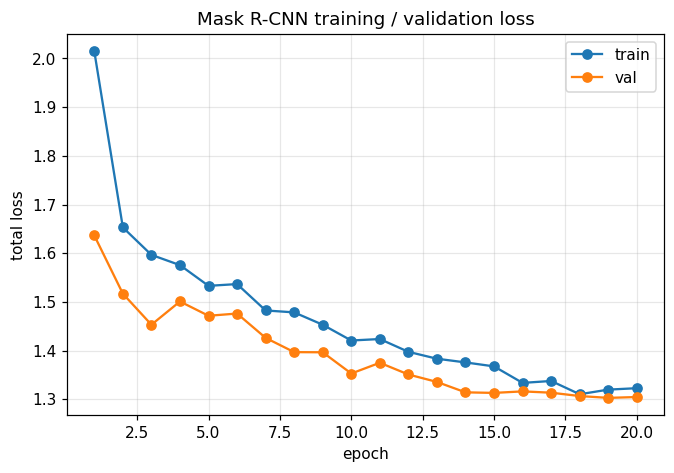

In [13]:
# ============================================
# LOSS CURVE
# ============================================

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(hist_df["epoch"], hist_df["train_loss"], marker="o", label="train")
ax.plot(hist_df["epoch"], hist_df["val_loss"], marker="o", label="val")
ax.set_xlabel("epoch")
ax.set_ylabel("total loss")
ax.set_title("Mask R-CNN training / validation loss")
ax.legend()
ax.grid(alpha=0.3)
fig.savefig(f"{CFG.OUT_DIR}/fig_loss_curve.png", bbox_inches="tight")
plt.show()

# CELL 13 - INFERENCE

In [14]:
# ============================================
# INFERENCE
# ============================================

model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=CFG.DEVICE))

model.eval()
print("best val loss:", best_loss)

best val loss: 1.3027754426002502


/tmp/ipykernel_3939439/2177318252.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=CFG.DEVICE))


# CELL 14 - THRESHOLD TUNING

In [15]:
# ============================================
# DICE SCORE
# ============================================


def dice_score(pred, target):

    pred = pred.astype(np.bool_)
    target = target.astype(np.bool_)

    intersection = (pred & target).sum()

    return (2. * intersection) / (pred.sum() + target.sum() + 1e-6)

In [16]:
# ============================================
# COMBINE INSTANCE MASKS
# ============================================


def combine_masks(masks, threshold):

    combined = np.zeros(masks.shape[-2:], dtype=np.uint8)

    for m in masks:
        m = m[0]
        m = (m > threshold).astype(np.uint8)

        combined = np.maximum(combined, m)

    return combined

In [17]:
# ============================================
# THRESHOLD TUNING (random validation subsets)
# ============================================

thresholds = np.arange(CFG.THRESHOLD_MIN, CFG.THRESHOLD_MAX, 0.05)

results = {}

model.eval()

rng = random.Random(SEED)
subsets = [rng.sample(list(val_ids), CFG.SUBSET_SIZE) for _ in range(CFG.N_ROUNDS)]

needed = sorted({i for s in subsets for i in s})

# every image is predicted once and scored at all thresholds
dice_table = {}

for image_id in tqdm(needed, desc="scoring val images"):

    image = cv2.imread(f"{CFG.TRAIN_IMG_DIR}/{image_id}.png")
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    image_tensor = TF.to_tensor(image).to(CFG.DEVICE)

    with torch.no_grad():
        pred = model([image_tensor])[0]

    masks = pred["masks"].cpu().numpy()

    gt_mask = np.zeros(image.shape[:2], dtype=np.uint8)
    for rle in ANN[image_id]:
        gt_mask = np.maximum(gt_mask, rle_decode(rle, image.shape[:2]))

    dice_table[image_id] = {
        float(thr): dice_score(combine_masks(masks, thr), gt_mask)
        for thr in thresholds
    }

    del masks, pred
    gc.collect()

for thr in thresholds:

    round_scores = [
        np.mean([dice_table[i][float(thr)] for i in subset_ids])
        for subset_ids in subsets
    ]

    final_score = float(np.mean(round_scores))

    results[float(thr)] = final_score

    print(f"Threshold {thr:.2f} -> Dice {final_score:.4f}")

scoring val images:   0%|          | 0/66 [00:00<?, ?it/s]

Threshold 0.30 -> Dice 0.6952
Threshold 0.35 -> Dice 0.7024
Threshold 0.40 -> Dice 0.7080
Threshold 0.45 -> Dice 0.7124
Threshold 0.50 -> Dice 0.7149
Threshold 0.55 -> Dice 0.7159
Threshold 0.60 -> Dice 0.7147
Threshold 0.65 -> Dice 0.7110
Threshold 0.70 -> Dice 0.7044


Best threshold: 0.5499999999999999
Best Dice: 0.715931955804488


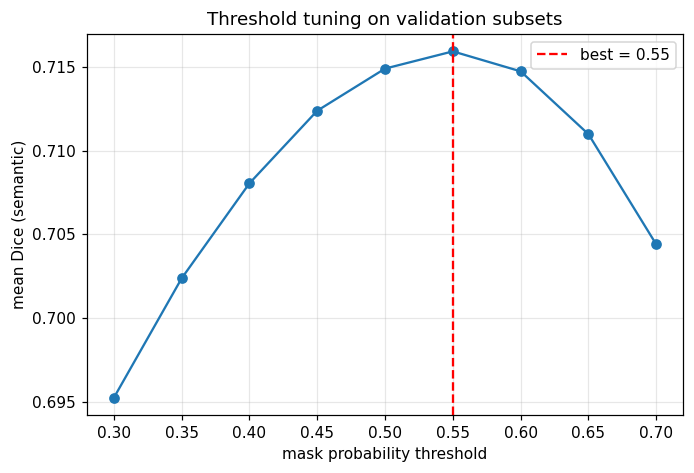

In [18]:
best_thr = max(results, key=results.get)

print("Best threshold:", best_thr)
print("Best Dice:", results[best_thr])

CFG.THRESHOLD = best_thr

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(list(results.keys()), list(results.values()), marker="o")
ax.axvline(best_thr, color="red", ls="--", label=f"best = {best_thr:.2f}")
ax.set_xlabel("mask probability threshold")
ax.set_ylabel("mean Dice (semantic)")
ax.set_title("Threshold tuning on validation subsets")
ax.legend()
ax.grid(alpha=0.3)
fig.savefig(f"{CFG.OUT_DIR}/fig_threshold.png", bbox_inches="tight")
plt.show()

# CELL 15 - PREDICTION HELPER

In [19]:
# ============================================
# PREDICT
# ============================================


def predict_image(image):

    image = TF.to_tensor(image).to(CFG.DEVICE)

    with torch.no_grad():

        pred = model([image])[0]

    masks = pred["masks"].cpu().numpy()

    masks = masks > CFG.THRESHOLD

    return masks

# CELL 16 - VISUALIZE PREDICTION

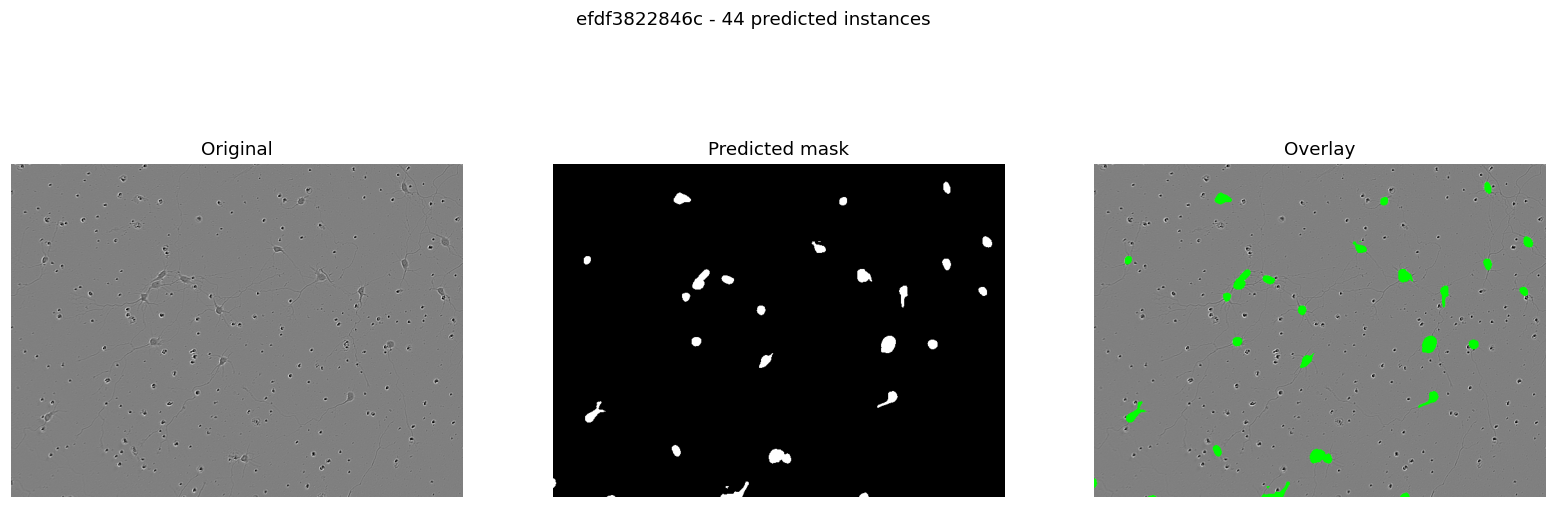

In [20]:
# ============================================
# VISUALIZE PREDICTION
# ============================================


def visualize_prediction(image_id, save_path=None):

    path = f"{CFG.TRAIN_IMG_DIR}/{image_id}.png"

    image = cv2.imread(path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    masks = predict_image(image)

    combined = np.zeros(image.shape[:2])

    for m in masks:
        combined = np.maximum(combined, m[0])

    overlay = image.copy()
    overlay[combined > 0] = [0, 255, 0]

    fig, ax = plt.subplots(1, 3, figsize=(18, 6))

    ax[0].imshow(image)
    ax[0].set_title("Original")
    ax[1].imshow(combined, cmap="gray")
    ax[1].set_title("Predicted mask")
    ax[2].imshow(overlay)
    ax[2].set_title("Overlay")

    for a in ax:
        a.axis("off")

    fig.suptitle(f"{image_id} - {len(masks)} predicted instances")

    if save_path:
        fig.savefig(save_path, bbox_inches="tight")

    plt.show()


visualize_prediction(val_ids[0], save_path=f"{CFG.OUT_DIR}/fig_prediction.png")

# CELL 16B - TRAIN / VALIDATION / TEST REGION CONFIDENCE



Compare ground-truth cell regions with model predictions and visualize pixel-level cell probabilities. Train and validation metrics use the true masks. Test images have no ground truth, so their ROI/background values are reported only as model self-confidence, not accuracy.

In [ ]:
# ============================================
# STEP 1: LOAD SAVED MODEL AND COMPARE GT VS PREDICTED CELL REGION
# ============================================

import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torchvision.models.detection import maskrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor
from torchvision.transforms import functional as TF

DATA_DIR = "/home/Data_Drive_8TB/kykim/7. Kaggle/Cell_Instance_Segmentation"
MODEL_PATH = f"{DATA_DIR}/outputs_augmented/best_model.pth"
FIGURE_PATH = "/home/Data_Drive_8TB/kykim/0. Jupyter/Kaggle/cell-Seg/validation_gt_vs_prediction.png"
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
MASK_THRESHOLD = 0.55
SCORE_THRESHOLD = 0.50

print("Inference device:", DEVICE)
if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(DEVICE))

train_df_validation = pd.read_csv(f"{DATA_DIR}/train.csv")
all_image_ids = train_df_validation["id"].unique()
rng = np.random.RandomState(42)
permutation = rng.permutation(len(all_image_ids))
number_of_validation_images = int(np.ceil(len(all_image_ids) * 0.2))
validation_indices = permutation[:number_of_validation_images]
training_indices = permutation[number_of_validation_images:]
validation_ids_for_plot = all_image_ids[validation_indices]
training_ids_for_plot = all_image_ids[training_indices]
annotations_by_image = train_df_validation.groupby("id")["annotation"].apply(list).to_dict()


def decode_rle_for_plot(encoded_mask, shape):
    values = encoded_mask.split()
    starts = np.asarray(values[0::2], dtype=int) - 1
    lengths = np.asarray(values[1::2], dtype=int)
    mask = np.zeros(shape[0] * shape[1], dtype=np.uint8)
    for start, length in zip(starts, lengths):
        mask[start:start + length] = 1
    return mask.reshape(shape)


def ground_truth_union(image_id, shape):
    combined = np.zeros(shape, dtype=np.uint8)
    for encoded_mask in annotations_by_image.get(image_id, []):
        combined = np.maximum(combined, decode_rle_for_plot(encoded_mask, shape))
    return combined


def build_validation_model():
    network = maskrcnn_resnet50_fpn(weights=None, weights_backbone=None)
    box_features = network.roi_heads.box_predictor.cls_score.in_features
    network.roi_heads.box_predictor = FastRCNNPredictor(box_features, 2)
    mask_features = network.roi_heads.mask_predictor.conv5_mask.in_channels
    network.roi_heads.mask_predictor = MaskRCNNPredictor(mask_features, 256, 2)
    network.roi_heads.score_thresh = SCORE_THRESHOLD
    network.roi_heads.detections_per_img = 600
    network.rpn._post_nms_top_n = {"training": 2000, "testing": 2000}
    state = torch.load(MODEL_PATH, map_location="cpu", weights_only=True)
    network.load_state_dict(state)
    return network.to(DEVICE).eval()


validation_model = build_validation_model()
print("Model parameter device:", next(validation_model.parameters()).device)


def predict_cell_region(image):
    image_tensor = TF.to_tensor(image).to(DEVICE)
    with torch.inference_mode():
        output = validation_model([image_tensor])[0]
    keep = output["scores"] >= SCORE_THRESHOLD
    if keep.any():
        probability_map = output["masks"][keep, 0].amax(dim=0).cpu().numpy()
    else:
        probability_map = np.zeros(image.shape[:2], dtype=np.float32)
    return probability_map > MASK_THRESHOLD


cell_counts = train_df_validation.groupby("id").size()
def median_density_id(ids):
    ordered = cell_counts.reindex(ids).sort_values()
    return ordered.index[len(ordered) // 2]


test_ids_for_plot = sorted(
    filename[:-4] for filename in os.listdir(f"{DATA_DIR}/test") if filename.endswith(".png")
)
plot_samples = [
    ("Train", median_density_id(training_ids_for_plot), f"{DATA_DIR}/train", True),
    ("Validation", median_density_id(validation_ids_for_plot), f"{DATA_DIR}/train", True),
    ("Test", test_ids_for_plot[0], f"{DATA_DIR}/test", False),
]

fig, axes = plt.subplots(3, 4, figsize=(18, 12), constrained_layout=True)
for row, (split_name, image_id, image_directory, has_ground_truth) in enumerate(plot_samples):
    image = cv2.imread(f"{image_directory}/{image_id}.png")
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    predicted_region = predict_cell_region(image)
    ground_truth = ground_truth_union(image_id, image.shape[:2]) if has_ground_truth else None

    axes[row, 0].imshow(image)
    axes[row, 0].set_title(f"{split_name}: original\n{image_id}")

    if ground_truth is not None:
        axes[row, 1].imshow(ground_truth, cmap="gray", vmin=0, vmax=1)
        axes[row, 1].set_title("Ground-truth cell region")
    else:
        axes[row, 1].imshow(np.zeros(image.shape[:2]), cmap="gray", vmin=0, vmax=1)
        axes[row, 1].text(0.5, 0.5, "Ground truth unavailable", color="white", ha="center", va="center", transform=axes[row, 1].transAxes)
        axes[row, 1].set_title("Test ground truth")

    axes[row, 2].imshow(predicted_region, cmap="gray", vmin=0, vmax=1)
    axes[row, 2].set_title(f"Predicted cell region\nmask p > {MASK_THRESHOLD:.2f}")

    axes[row, 3].imshow(image)
    if ground_truth is not None:
        axes[row, 3].contour(ground_truth, levels=[0.5], colors="lime", linewidths=1.2)
    if predicted_region.any():
        axes[row, 3].contour(predicted_region, levels=[0.5], colors="red", linewidths=1.0)
    axes[row, 3].set_title("GT green / prediction red" if has_ground_truth else "Prediction red (no GT)")

    for axis in axes[row]:
        axis.axis("off")

fig.suptitle("Saved augmented model: ground truth vs learned cell region", fontsize=17)
fig.savefig(FIGURE_PATH, dpi=150, bbox_inches="tight")
plt.show()
print("Saved figure:", FIGURE_PATH)

### Ground truth vs predicted cell region

![Train, validation, and test cell-region comparison](validation_gt_vs_prediction.png)

In [ ]:
# ============================================
# STEP 2: CELL-PROBABILITY HEATMAP ON IMAGE
# ============================================

PROBABILITY_FIGURE_PATH = "/home/Data_Drive_8TB/kykim/0. Jupyter/Kaggle/cell-Seg/validation_cell_probability.png"


def predict_cell_probability(image):
    image_tensor = TF.to_tensor(image).to(DEVICE)
    with torch.inference_mode():
        output = validation_model([image_tensor])[0]

    keep = output["scores"] >= SCORE_THRESHOLD
    if keep.any():
        return output["masks"][keep, 0].amax(dim=0).cpu().numpy()
    return np.zeros(image.shape[:2], dtype=np.float32)


fig, axes = plt.subplots(3, 2, figsize=(12, 14), constrained_layout=True)
for row, (split_name, image_id, image_directory, _) in enumerate(plot_samples):
    image = cv2.imread(f"{image_directory}/{image_id}.png")
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    probability_map = predict_cell_probability(image)

    axes[row, 0].imshow(image)
    axes[row, 0].set_title(f"{split_name}: original\n{image_id}")

    axes[row, 1].imshow(image)
    heatmap = axes[row, 1].imshow(
        probability_map,
        cmap="turbo",
        vmin=0,
        vmax=1,
        alpha=0.65,
    )
    axes[row, 1].set_title(
        f"Cell-probability overlay\nmean={probability_map.mean():.3f}, max={probability_map.max():.3f}"
    )

    for axis in axes[row]:
        axis.axis("off")

colorbar = fig.colorbar(heatmap, ax=axes[:, 1], shrink=0.75, pad=0.02)
colorbar.set_label("Cell probability")
fig.suptitle("Saved augmented model: cell-region probability heatmaps", fontsize=17)
fig.savefig(PROBABILITY_FIGURE_PATH, dpi=150, bbox_inches="tight")
plt.show()
print("Saved figure:", PROBABILITY_FIGURE_PATH)

### Cell-region probability heatmap

![Train, validation, and test cell-probability overlays](validation_cell_probability.png)

In [ ]:
# ============================================
# STEP 3: ROI VS BACKGROUND CONFIDENCE AND SEPARATION
# ============================================

CONFIDENCE_FIGURE_PATH = "/home/Data_Drive_8TB/kykim/0. Jupyter/Kaggle/cell-Seg/validation_roi_background_confidence.png"
confidence_rows = []

for split_name, image_id, image_directory, has_ground_truth in plot_samples:
    image = cv2.imread(f"{image_directory}/{image_id}.png")
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    probability_map = predict_cell_probability(image)

    if has_ground_truth:
        roi_mask = ground_truth_union(image_id, image.shape[:2]).astype(bool)
        confidence_reference = "Ground-truth ROI"
    else:
        roi_mask = probability_map > MASK_THRESHOLD
        confidence_reference = "Predicted ROI (self-confidence)"

    background_mask = ~roi_mask
    roi_confidence = float(probability_map[roi_mask].mean()) if roi_mask.any() else 0.0
    background_cell_probability = (
        float(probability_map[background_mask].mean()) if background_mask.any() else 0.0
    )
    background_confidence = 1.0 - background_cell_probability
    separation = roi_confidence - background_cell_probability

    confidence_rows.append({
        "split": split_name,
        "image_id": image_id,
        "reference": confidence_reference,
        "roi_confidence": roi_confidence,
        "background_confidence": background_confidence,
        "background_cell_probability": background_cell_probability,
        "roi_background_separation": separation,
    })

confidence_df = pd.DataFrame(confidence_rows)

x = np.arange(len(confidence_df))
width = 0.24
fig, ax = plt.subplots(figsize=(11, 5.5), constrained_layout=True)
roi_bars = ax.bar(
    x - width,
    confidence_df["roi_confidence"],
    width,
    label="ROI confidence: mean P(cell) in ROI",
    color="#d95f02",
)
background_bars = ax.bar(
    x,
    confidence_df["background_confidence"],
    width,
    label="Background confidence: mean 1-P(cell) in background",
    color="#1b9e77",
)
separation_bars = ax.bar(
    x + width,
    confidence_df["roi_background_separation"],
    width,
    label="Separation: ROI P(cell) - background P(cell)",
    color="#7570b3",
)

ax.set_xticks(x)
ax.set_xticklabels(confidence_df["split"])
ax.set_ylim(0, 1.05)
ax.set_ylabel("Confidence / separation")
ax.set_title("Saved augmented model: ROI vs background confidence")
ax.grid(axis="y", alpha=0.25)
ax.legend(loc="lower right")
ax.bar_label(roi_bars, fmt="%.3f", fontsize=9)
ax.bar_label(background_bars, fmt="%.3f", fontsize=9)
ax.bar_label(separation_bars, fmt="%.3f", fontsize=9)

fig.savefig(CONFIDENCE_FIGURE_PATH, dpi=150, bbox_inches="tight")
plt.show()
print("Saved figure:", CONFIDENCE_FIGURE_PATH)
confidence_df.round(4)

### ROI vs background confidence

![ROI confidence, background confidence, and separation](validation_roi_background_confidence.png)

- **ROI confidence**: ROI 내부의 평균 cell probability
- **Background confidence**: 배경 내부의 평균 `1 - cell probability`
- **Separation**: ROI 평균 cell probability - 배경 평균 cell probability
- Test에는 GT가 없으므로 predicted ROI 기준 self-confidence입니다.

# CELL 17 - SUBMISSION

In [ ]:
test_ids = []

for f in sorted(os.listdir(CFG.TEST_IMG_DIR)):
    if f.endswith(".png"):
        test_ids.append(f.replace(".png", ""))

print("Test images:", len(test_ids))
print(test_ids[:5])

Test images: 3
['7ae19de7bc2a', 'd48ec7815252', 'd8bfd1dafdc4']


In [ ]:
model.eval()

submission = []

for image_id in tqdm(test_ids, desc="predict test"):

    image = cv2.imread(f"{CFG.TEST_IMG_DIR}/{image_id}.png")
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    h, w = image.shape[:2]

    tensor = TF.to_tensor(image).unsqueeze(0).to(CFG.DEVICE)

    with torch.no_grad():
        output = model(tensor)[0]

    masks = output["masks"].cpu().numpy()
    scores = output["scores"].cpu().numpy()

    used = np.zeros((h, w), dtype=bool)

    count = 0

    for mask, score in zip(masks, scores):

        if score < 0.5:
            continue

        mask = mask[0] > CFG.THRESHOLD

        if mask.sum() < CFG.MIN_MASK_AREA:
            continue

        # remove overlap (the competition metric forbids overlapping masks)
        mask = mask & (~used)

        if mask.sum() < CFG.MIN_MASK_AREA:
            continue

        used = used | mask

        submission.append([image_id, rle_encode(mask.astype(np.uint8))])

        count += 1

    if count == 0:
        submission.append([image_id, "1 1"])

print("predicted instances:", len(submission))

predict test:   0%|          | 0/3 [00:00<?, ?it/s]

predicted instances: 166


In [ ]:
# --------------------------------
# build dataframe
# --------------------------------

sub = pd.DataFrame(submission, columns=["id", "predicted"])

sub["predicted"] = sub["predicted"].astype(str)

sub = sub.sort_values("id").reset_index(drop=True)

sub.to_csv(f"{CFG.OUT_DIR}/submission_b.csv", index=False)
sub.to_csv(CFG.SUBMISSION_PATH, index=False)

print(sub.head())
print("rows:", len(sub))
print("unique images:", sub["id"].nunique())

             id                                          predicted
0  7ae19de7bc2a  140005 9 140708 17 141411 20 142115 20 142819 ...
1  7ae19de7bc2a  293888 7 294590 10 295294 11 295997 13 296701 ...
2  7ae19de7bc2a  1153 5 1856 7 2559 9 3263 10 3966 12 4670 12 5...
3  7ae19de7bc2a  46202 10 46902 14 47604 16 48306 17 49008 19 4...
4  7ae19de7bc2a  119518 3 120221 8 120924 11 121628 12 122331 1...
rows: 166
unique images: 3


# CELL 18 - EXPORT METRICS FOR THE REPORT

In [ ]:
metrics = {
    "data": data_stats,
    "config": {
        "epochs_configured": CFG.EPOCHS,
        "epochs_run": int(hist_df["epoch"].max()),
        "batch_size": CFG.BATCH_SIZE,
        "lr": CFG.LR,
        "weight_decay": CFG.WEIGHT_DECAY,
        "amp": CFG.AMP,
        "grad_clip": CFG.GRAD_CLIP,
        "early_stopping": CFG.EARLY_STOPPING,
        "num_classes": CFG.NUM_CLASSES,
        "min_mask_area": CFG.MIN_MASK_AREA,
        "device": CFG.DEVICE,
        "augmentation": {
            "horizontal_flip_probability": CFG.HFLIP_PROB,
            "vertical_flip_probability": CFG.VFLIP_PROB,
            "rotation_probability": CFG.ROTATE_PROB,
            "rotation_range_degrees": CFG.ROTATE_RANGE,
            "scale_probability": CFG.SCALE_PROB,
            "scale_range": CFG.SCALE_RANGE,
        },
    },
    "training": {
        "best_val_loss": float(best_loss),
        "final_train_loss": float(hist_df["train_loss"].iloc[-1]),
        "final_val_loss": float(hist_df["val_loss"].iloc[-1]),
        "history": history,
    },
    "threshold_tuning": {
        "scores": {f"{k:.2f}": v for k, v in results.items()},
        "best_threshold": float(best_thr),
        "best_dice": float(results[best_thr]),
        "n_rounds": CFG.N_ROUNDS,
        "subset_size": CFG.SUBSET_SIZE,
    },
    "submission": {
        "rows": int(len(sub)),
        "unique_images": int(sub["id"].nunique()),
        "test_images": int(len(test_ids)),
    },
}

with open(f"{CFG.OUT_DIR}/metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

print(json.dumps({k: v for k, v in metrics.items() if k != "training"}, indent=2))

{
  "data": {
    "n_annotations": 73585,
    "n_images": 606,
    "n_train": 484,
    "n_val": 122,
    "cell_type_counts": {
      "shsy5y": 52286,
      "cort": 10777,
      "astro": 10522
    },
    "cells_per_image_mean": 121.42739273927393,
    "cells_per_image_median": 46.0,
    "cells_per_image_min": 4,
    "cells_per_image_max": 790
  },
  "config": {
    "epochs_configured": 20,
    "epochs_run": 20,
    "batch_size": 2,
    "lr": 0.0002,
    "weight_decay": 0.0001,
    "amp": true,
    "grad_clip": 1.0,
    "early_stopping": 5,
    "num_classes": 2,
    "min_mask_area": 30,
    "device": "cuda",
    "augmentation": {
      "horizontal_flip_probability": 0.5,
      "vertical_flip_probability": 0.5,
      "rotation_probability": 0.75,
      "rotation_range_degrees": [
        -30.0,
        30.0
      ],
      "scale_probability": 0.5,
      "scale_range": [
        0.85,
        1.15
      ]
    }
  },
  "threshold_tuning": {
    "scores": {
      "0.30": 0.6952236368011485,
